In [1]:
import os
import math
import time
from datetime import datetime
from dataclasses import dataclass
from IPython.display import display, Markdown
from typing import Dict, TypedDict, List, Union, Any

from pydantic import BaseModel
from langchain_community.vectorstores import Chroma
from langchain_core.tools import create_retriever_tool
from langchain_core.retrievers import BaseRetriever
from langchain_core.documents import Document
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langgraph.graph import StateGraph, START, END

from rich.console import Console
from rich.markdown import Markdown

/Users/ankit/Projects/learn_llm/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
gemini_llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0, max_tokens=None, timeout=None, max_retries=2) # Or "gemini-pro"

llm = ChatOllama(model="qwen2.5:14b-instruct", temperature=0.2) 

vector_store = Chroma(persist_directory="vector_db/ircc", embedding_function=OllamaEmbeddings(model="qwen3-embedding:0.6b"))
print("Total documents:", vector_store._collection.count())

/var/folders/ng/dp6yvncx7pl1qbny9711g9hr0000gn/T/ipykernel_28610/545089355.py:6: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(persist_directory="vector_db/ircc", embedding_function=OllamaEmbeddings(model="qwen3-embedding:0.6b"))


Total documents: 4597


In [3]:
class GraphState(TypedDict):
    question: str
    chat_history: List[Dict[str, str]]
    user_profile: Dict[str, Any]
    sub_queries: List[str]
    retrieved_docs: List[Document]
    context: str
    final_answer: str
    missing_info: List[str]
    retry_count: int
    citations: List[str]
    
    
class QueryPlan(BaseModel):
    sub_queries: List[str]


class AnswerOutput(BaseModel):
    answer: str
    missing_information: List[str]
    citations: List[str]

In [31]:
class LatestFirstRetriever:
    def __init__(self, vector_store, k=10):
        self.vector_store: Chroma = vector_store
        self.k: int = k

    def search(self, query: str) -> List[Document]:
        docs_with_score = self.vector_store.similarity_search_with_score(
            query,
            k=20,
            filter={"archived": False}
        )

        ranked = []

        for doc, score in docs_with_score:

            similarity_score = 1 / (1 + score)

            date_obj = datetime.strptime(doc.metadata["date"], "%Y-%m-%d")
            days_old = (datetime.now() - date_obj).days
            recency_score = math.exp(-days_old / 365)

            
            # recency_score = date_object.timestamp()
            final_score = (similarity_score * 0.8) + (recency_score * 0.2)
            doc.page_content = f"""URL: {doc.metadata.get("url")}\n Content: {doc.page_content.split("Content:")[-1]}"""
            ranked.append((doc, final_score))

            # ranked.append((doc, final_score, score, similarity_score * 0.8, recency_score * 0.2))

        ranked.sort(key=lambda x: x[1], reverse=True)        
        return [d for d, _ in ranked[:self.k]]

        
hybrid_retriever = LatestFirstRetriever(vector_store, k=10)
def retrieval_node(state: GraphState):
    all_docs = []

    for query in state["sub_queries"]:
        docs = hybrid_retriever.search(query)
        all_docs.extend(docs)

    # Deduplicate
    unique = {}
    for doc in all_docs:
        unique[doc.metadata["doc_id"]] = doc
    state['retrieved_docs'] = list(unique.values())
    
    return state

In [8]:
# docs = hybrid_retriever.search("crs score for 1 year of canadian experience")
# for doc in docs:
#     print(doc.page_content[:500])
#     print("\n\n")

In [32]:
def profile_extractor_node(state: GraphState):
    prompt = f"""
    Extract structured immigration-related facts from the conversation.

    Existing profile:
    {state.get('user_profile', {})}

    New message:
    {state['question']}

    Update the profile with any new facts.

    Return JSON.
    """

    response = llm.invoke(prompt)

    # assuming response is JSON
    updated_profile = eval(response.content)
    state['user_profile'] = updated_profile
    
    return state

In [28]:
def planner_node(state: GraphState):
    missing = state.get("missing_info", [])

    if state["chat_history"]:
        history_text = "\n".join([f"{m['role']}: {m['content']}" for m in state["chat_history"]])
        prompt = f"""
        Conversation so far:
        {history_text}
        
        """
    else:
        prompt = ""

    prompt += f"""        
        Original question:
        {state['question']}
        
        """
    
    if missing:
        prompt += f"""Previously missing information:
        {missing}
    
        Generate NEW retrieval queries specifically to obtain missing information.
        Be precise and focused.
        """
        state['missing_info'] = []
    else:
        prompt += f"Break this into retrieval sub-queries."
    
    print(prompt)
    structured_llm = llm.with_structured_output(QueryPlan)
    plan = structured_llm.invoke(prompt)

    state["sub_queries"] = plan.sub_queries
    state["retry_count"] = state.get("retry_count", 0) + 1

    return state

In [11]:
def aggregation_node(state: GraphState):
    context = ""
    max_chars = 15000

    for doc in state["retrieved_docs"]:
        if len(context) + len(doc.page_content) > max_chars:
            break
        context += "\n\n" + doc.page_content
    state["context"] = context

    return state

In [12]:
def answer_node(state: GraphState):
    prompt = f"""
    You are an expert assistant.

    Use ONLY the provided context.

    If any required information is missing,
    list EXACT missing categories.

    Context:
    {state['context']}

    Question:
    {state['question']}

    Return structured JSON:
    {{
      "answer": "...",
      "missing_information": ["item1", "item2"]
      "citations": ["URL1", "URL2"]
    }}
    """

    structured_llm = gemini_llm.with_structured_output(AnswerOutput)
    result = structured_llm.invoke(prompt)
    
    state["final_answer"] = result.answer
    state["missing_info"] = result.missing_information
    state["citations"] = result.citations

    return state

In [13]:
MAX_RETRIES = 2

def router_node(state: GraphState):
    return {}  # no state modification
    
def route_decision(state: GraphState):
    if state["missing_info"] and state["retry_count"] < MAX_RETRIES:
        return "replan"
    return "end"

In [14]:
def update_chat_history(state: GraphState):
    updated_history = state["chat_history"] + [
        {"role": "user", "content": state["question"]},
        {"role": "assistant", "content": state["final_answer"]}
    ]
    state["chat_history"] = updated_history

    return state

In [15]:
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("planner", planner_node)
workflow.add_node("retrieve", retrieval_node)
workflow.add_node("aggregate", aggregation_node)
workflow.add_node("answer", answer_node)
workflow.add_node("router", router_node)
workflow.add_node("update_chat_history", update_chat_history)


# Define flow
workflow.set_entry_point("planner")

workflow.add_edge("planner", "retrieve")
workflow.add_edge("retrieve", "aggregate")
workflow.add_edge("aggregate", "answer")
workflow.add_edge("answer", "router")

workflow.add_conditional_edges(
    "router",
    route_decision,
    {
        "replan": "planner",
        "end": "update_chat_history"
    }
)

workflow.add_edge("update_chat_history", END)


app = workflow.compile()

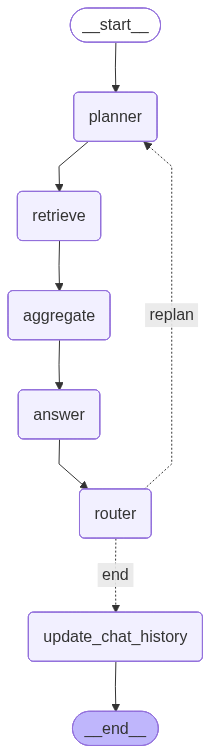

In [16]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

In [29]:
# query = """
#     Calculate my CRS score for express entry canadian experience class PR pathway:
#     my age is 31
#     IELTS scores reading 7, speaking 7, writing 7, listening 8
#     I studied Master's degree with 2 years course in canada
#     1 year canadian experience in noc A category 
#     1 year of foreign experience in noc A category 
#     I am unmarried
#     I do not have any job offer letter 
#     my sibling is candain citizen
#     """
# query="""what are valid exames to prove proficency in English and French language. """
query="""what are all the available programmes to get become PR. include currently working and closed programmes"""

result = app.invoke({
"question": query,
"user_profile": {"user_id":'ankit1'},
"chat_history": []
})

# result = app.invoke({
# "question": """
#     what are valid exames to prove proficency in English and French language. 
#     """,
# "user_profile": {"user_id":'ankit1'},
# "chat_history": []
# })


display(Markdown(result["final_answer"] +"\n\n" + " \n\n".join(result["citations"])))

Available programs to become a permanent resident (PR) in Canada include:                                          

 • Rural and Northern Immigration Pilot                                                                            
 • Canadian experience class                                                                                       
 • Federal Skilled Worker Program                                                                                  
 • Provincial Nominee Program                                                                                      
 • Quebec Skilled Worker Class                                                                                     

https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/rural-northern-immigration-pilo
t/pr-eligibility.html                                                                                              

https://www.canada.ca/en/immigration-refugees-citizenship/services/study-canada/graduate-student/how-to-apply.html 

https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/quebec-skilled-workers/apply/gu
ide-q7000-application-permanent-residence-quebec-skilled-worker-class.html

In [21]:
result.keys()

dict_keys(['question', 'chat_history', 'user_profile', 'sub_queries', 'retrieved_docs', 'context', 'final_answer', 'missing_info', 'retry_count', 'citations'])

In [27]:
result['retry_count']

2

In [30]:
for doc in result['retrieved_docs']:
    print(doc.page_content[:500])
    print("\n\n")

URL: https://www.canada.ca/en/immigration-refugees-citizenship/services/permanent-residents.html
 Content:  Sign in to the permanent residence portal Check your application status Check processing times Become a Canadian citizen

.



URL: https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/rural-northern-immigration-pilot/pr-eligibility.html
 Content:  Credential here means a degree, diploma, certificate, or trade or apprenticeship from a Canadian publicly funded institution in the community recommending you. You must also have had valid temporary resident status for the duration of your studies.

.



URL: https://www.canada.ca/en/immigration-refugees-citizenship/services/immigrate-canada/rural-northern-immigration-pilot/pr-eligibility.html
 Content:  You must meet the minimum language requirements based on the NOC category that applies to the job offer in the community. This can either be the Canadian Language Benchmarks (CLB) or Niveaux de compétence

In [ ]:
Hello my name is Ankit. I have one year of Canadian experience what is the best programme for me to get PR?
# am I eligible for Express Entry - Canadian experience class? tell me more about that program.
# what is CRS score can you calculate my CRS score? ask me neccessory questions to calcualtes the score
# here is my details calculate my score.
# Hello my name is Ankit. I speak English. I have one year of Canadian experience what is the best programme for me to get PR?
Age – 31.
Language Test Results – IELTS .
Scores for English (speaking, reading , writing, listening) are 7, 7, 7, 8.
Education Details – Master’s.
The duration of study 2 year.
Work Experience – Canada 1 year, abroad 1 year.
NOC (National Occupational Classification) level of  job: 1 – Professional.
Years of work experience in Canada (if applicable). 1 year in canada.
Spouse/Partner Details (if applicable) – unmarried .
If your spouse is a Canadian citizen or permanent resident, you may get additional points.- No.
Job Offer in Canada (if applicable) – No.
If you have a job offer from a designated employer, you may get extra points. - No.
I studied computer science and I am working in AI. is there any programme based on in demand skills?
can i apply for green card in usa?
is there any provincial progamme where i can be eligible ?
i heard that there is fifa in canada this year can i apply for my family's visa to watch fifa?

In [ ]:
result.keys()

In [ ]:
print(result['sub_queries'])

In [ ]:
from langchain.messages import ToolMessage, AIMessage, HumanMessage, SystemMessage
from pprint import pprint
for m in  result['messages']:
    # pprint(m)
    if isinstance(m, HumanMessage):
        print("".join(['=']*70)+"Human Message"+"".join(['=']*70))
        print(m.content)
    elif isinstance(m, AIMessage):
        print("".join(['=']*70)+"AI Message"+"".join(['=']*70))
        if m.content:
            print(m.content[:200])
        if m.tool_calls:
            print("Tools call:" + m.tool_calls[0]['args']['query'])
    elif isinstance(m, ToolMessage):
        print("".join(['=']*70)+"Tool Message"+"".join(['=']*70))
        print(m.content)
    elif isinstance(m, SystemMessage):
        print("".join(['=']*70)+"System Message"+"".join(['=']*70))
        print(m.content)
    else:
        pprint(m)
    print('\n\n')
# response['messages']

In [ ]:
docs[0]

In [ ]:
docs[0]

In [ ]:
query = "how to calculate CRS score for Canadian Experience Class (CEC) in Express Entry"

docs = retriever.invoke(query)

print(f"Returned {len(docs)} documents\n")

for i, (d, ns, os, ss, rs) in enumerate(docs):
    print(f"--- Document {i+1}: New score:{s:.4f}: Old Score {os:.4f}:  ss {ss:.4f}:  rs {rs:.4f} ---")
    print("Date:", d.metadata.get("date"))
    print("Archived:", d.metadata.get("archived"))
    print("URL:", d.metadata.get("url"))
    print("Program:", d.metadata.get("category"))
    # print("Preview:", d.page_content[:300])
    print()